# Volatility Is Rough

In [ ]:
import numpy as np
import numpy.random as rd
import pandas as pd
import scipy.linalg as lalg
import scipy.stats as stats
from sklearn import datasets, linear_model
import matplotlib.pyplot as plt
#import seaborn
import datetime as dt
from __future__ import division
plt.rcParams['figure.figsize'] = (15., 15. / 16 * 9)

from statsmodels.graphics.tsaplots import *
%matplotlib inline

from scipy.special import gamma

/usr/local/lib/python3.7/dist-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [ ]:
from google.colab import drive
#drive.mount('/content/drive')
drive.mount('/content/drive',force_remount=True)

Mounted at /content/drive


## Replication on S&P x Nasdaq

In [ ]:
df = pd.read_csv('oxfordmanrealizedvolatilityindices.csv',sep=';',parse_dates=True)
df = df.rename(columns = {'Unnamed: 0': 'Date'})
df = df.dropna()
print(df.dtypes)

Date              object
Symbol            object
rk_th2           float64
rv5              float64
rk_parzen        float64
open_time        float64
rsv              float64
rv10_ss          float64
open_price       float64
close_time       float64
open_to_close    float64
nobs             float64
rv10             float64
medrv            float64
bv               float64
bv_ss            float64
rk_twoscale      float64
close_price      float64
rsv_ss           float64
rv5_ss           float64
dtype: object


In [ ]:
SPx = df[(df['Date'] < '2014-04-01') & (df['Symbol'] == '.SPX')]
SPx = SPx.set_index("Date")
SPx = SPx.iloc[:3500]
SPx['sqrt']= np.sqrt(SPx['rv5'])
SPx['log_sqrt'] = np.log(SPx['sqrt'])
SPx['log_rv']=np.log(SPx['rv5'])
SPx

,Symbol,rk_th2,rv5,rk_parzen,open_time,rsv,rv10_ss,open_price,close_time,open_to_close,nobs,rv10,medrv,bv,bv_ss,rk_twoscale,close_price,rsv_ss,rv5_ss,sqrt,log_sqrt,log_rv
Date,,,,,,,,,,,,,,,,,,,,,,
2000-01-03 00:00:00+00:00,.SPX,0.000130,0.000141,0.000340,83004.0,0.000096,0.000164,1471.21,145959.0,-0.011602,1554.0,0.000164,0.000058,0.000141,0.000141,0.000122,1454.24,0.000096,0.000141,0.011867,-4.434032,-8.868065
2000-01-04 00:00:00+00:00,.SPX,0.000162,0.000224,0.000215,83009.0,0.000180,0.000295,1449.00,150000.0,-0.035102,1564.0,0.000295,0.000067,0.000173,0.000173,0.000142,1399.02,0.000180,0.000224,0.014971,-4.201640,-8.403279
2000-01-05 00:00:00+00:00,.SPX,0.000240,0.000314,0.000163,83012.0,0.000131,0.000267,1395.62,150003.0,0.004625,1552.0,0.000267,0.000142,0.000303,0.000303,0.000219,1402.09,0.000131,0.000314,0.017728,-4.032610,-8.065219
2000-01-06 00:00:00+00:00,.SPX,0.000132,0.000131,0.000067,83005.0,0.000056,0.000115,1398.87,145954.0,0.002991,1561.0,0.000115,0.000070,0.000128,0.000128,0.000127,1403.06,0.000056,0.000131,0.011437,-4.470883,-8.941767
2000-01-07 00:00:00+00:00,.SPX,0.000095,0.000094,0.000215,83000.0,0.000023,0.000121,1403.45,150000.0,0.026293,1540.0,0.000121,0.000049,0.000079,0.000079,0.000091,1440.84,0.000023,0.000094,0.009676,-4.638124,-9.276248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-09 00:00:00+00:00,.SPX,0.000010,0.000012,0.000007,83002.0,0.000004,0.000010,1806.21,150001.0,0.001300,4681.0,0.000010,0.000005,0.000010,0.000010,0.000010,1808.56,0.000004,0.000012,0.003442,-5.671704,-11.343408
2013-12-10 00:00:00+00:00,.SPX,0.000014,0.000011,0.000009,83001.0,0.000006,0.000012,1807.60,145957.0,-0.002709,4680.0,0.000012,0.000005,0.000010,0.000010,0.000014,1802.71,0.000006,0.000011,0.003305,-5.712353,-11.424707
2013-12-11 00:00:00+00:00,.SPX,0.000024,0.000028,0.000034,83002.0,0.000020,0.000027,1802.76,150001.0,-0.011571,4681.0,0.000027,0.000022,0.000027,0.000027,0.000023,1782.02,0.000020,0.000028,0.005275,-5.244816,-10.489632


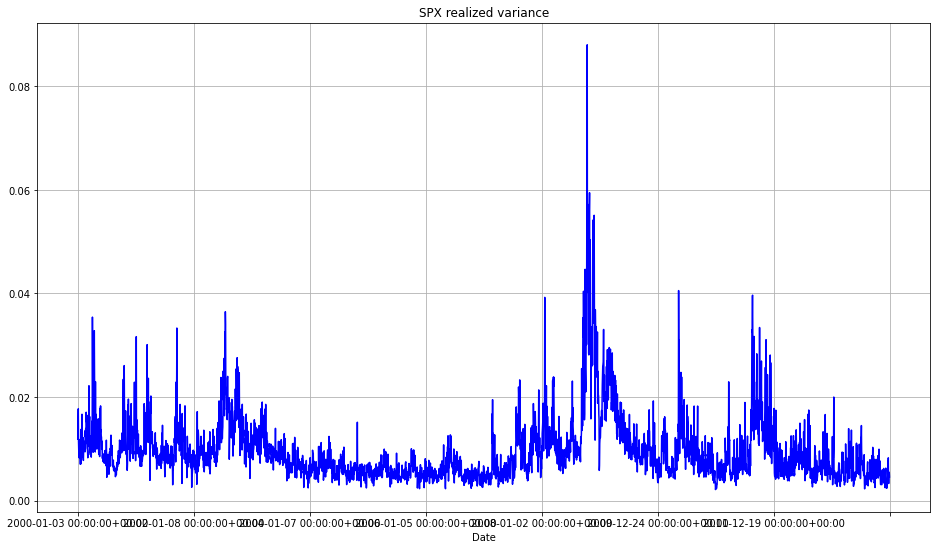

In [ ]:
SPx['sqrt'].plot(color='b', grid=True, title='SPX realized variance',figsize=(16, 9));

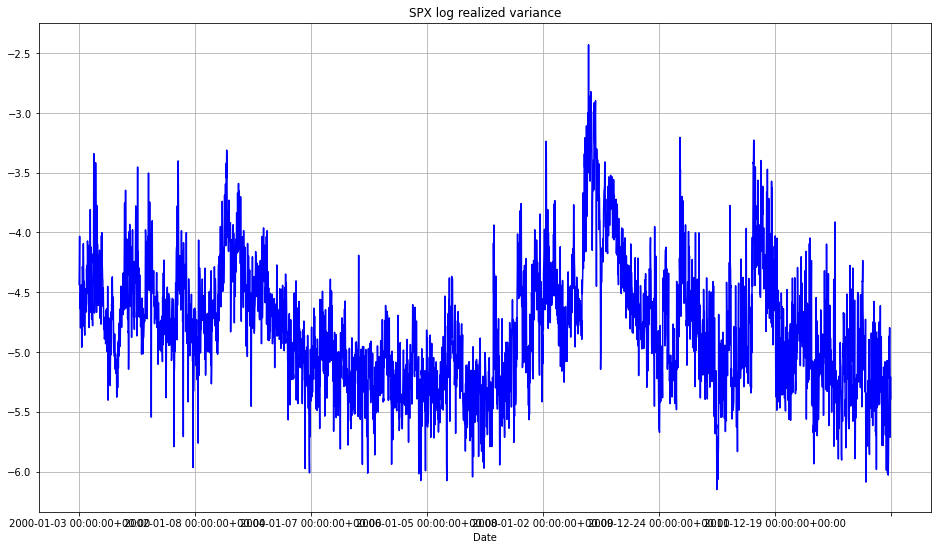

In [ ]:
SPx['log_sqrt'].plot(color='b', grid=True, title='SPX log realized variance',figsize=(16, 9));

In [ ]:
Nsdq = df[(df['Date'] < '2014-04-01') & (df['Symbol'] == '.IXIC')]
Nsdq = Nsdq.set_index("Date")
Nsdq = Nsdq.iloc[:3500]
Nsdq['sqrt']= np.sqrt(Nsdq['rv5'])
Nsdq['log_sqrt'] = np.log(Nsdq['sqrt'])
Nsdq

,Symbol,rk_th2,rv5,rk_parzen,open_time,rsv,rv10_ss,open_price,close_time,open_to_close,nobs,rv10,medrv,bv,bv_ss,rk_twoscale,close_price,rsv_ss,rv5_ss,sqrt,log_sqrt
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03 00:00:00+00:00,.IXIC,0.000425,0.000404,0.001291,93101.0,0.000276,0.000601,4186.190,160004.0,-0.013521,396.0,0.000601,0.000201,0.000444,0.000444,0.000364,4129.970,0.000276,0.000404,0.020089,-3.907587
2000-01-04 00:00:00+00:00,.IXIC,0.000462,0.000436,0.000646,93101.0,0.000287,0.000514,4020.000,160004.0,-0.029577,396.0,0.000514,0.000167,0.000424,0.000424,0.000405,3902.840,0.000287,0.000436,0.020881,-3.868931
2000-01-05 00:00:00+00:00,.IXIC,0.000787,0.000695,0.001122,93101.0,0.000374,0.001060,3854.350,160004.0,0.005645,396.0,0.001060,0.000366,0.000837,0.000837,0.000641,3876.170,0.000374,0.000695,0.026354,-3.636148
2000-01-06 00:00:00+00:00,.IXIC,0.000517,0.000436,0.000411,93101.0,0.000266,0.000447,3834.440,160101.0,-0.028541,397.0,0.000447,0.000156,0.000485,0.000485,0.000469,3726.550,0.000266,0.000436,0.020879,-3.869035
2000-01-07 00:00:00+00:00,.IXIC,0.000314,0.000297,0.000821,93102.0,0.000083,0.000431,3711.090,160004.0,0.044713,396.0,0.000431,0.000146,0.000324,0.000324,0.000278,3880.790,0.000083,0.000297,0.017230,-4.061131
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-12 00:00:00+00:00,.IXIC,0.000015,0.000032,0.000030,93015.0,0.000020,0.000026,4004.753,160015.0,-0.001587,48676.0,0.000026,0.000017,0.000027,0.000027,0.000017,3998.403,0.000020,0.000032,0.005700,-5.167251
2013-12-13 00:00:00+00:00,.IXIC,0.000014,0.000025,0.000027,93015.0,0.000016,0.000034,4015.533,160015.0,-0.003632,49362.0,0.000034,0.000019,0.000028,0.000028,0.000016,4000.975,0.000016,0.000025,0.005010,-5.296373
2013-12-16 00:00:00+00:00,.IXIC,0.000014,0.000020,0.000027,93015.0,0.000008,0.000026,4019.368,160015.0,0.002522,46382.0,0.000026,0.000008,0.000020,0.000020,0.000015,4029.518,0.000008,0.000020,0.004448,-5.415226


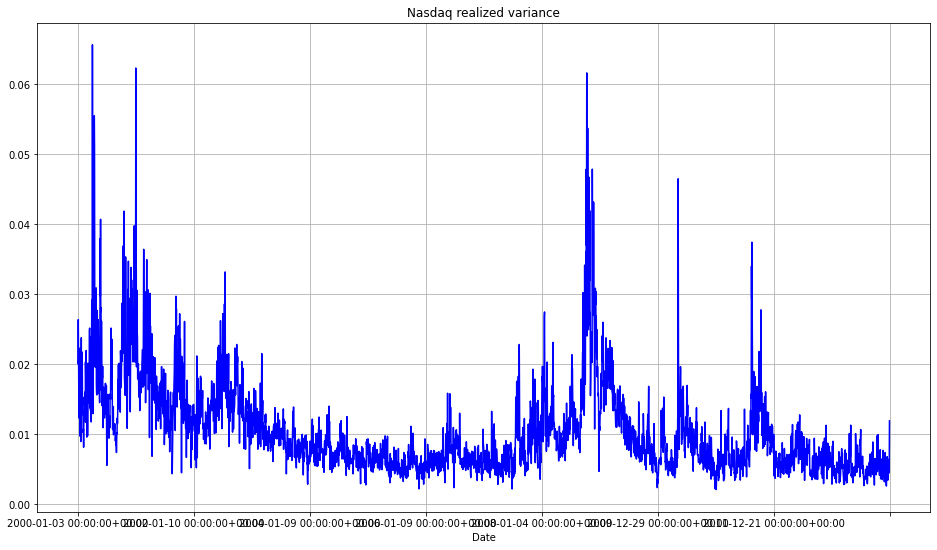

In [ ]:
Nsdq['sqrt'].plot(color='b', grid=True, title='Nasdaq realized variance',figsize=(16, 9));

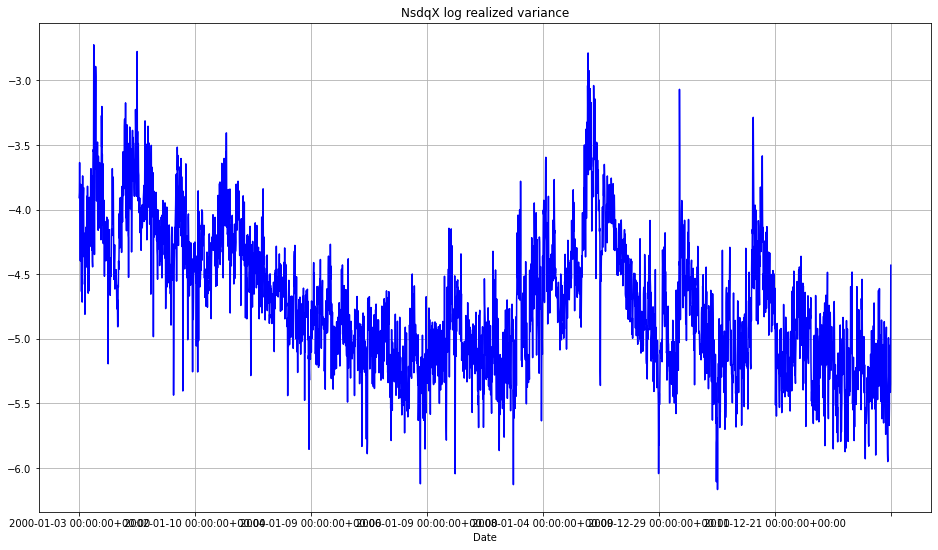

In [ ]:
Nsdq['log_sqrt'].plot(color='b', grid=True, title='NsdqX log realized variance',figsize=(16, 9));

# Partie Smoothness

In [ ]:
# we compute the empirical q-variation of the log volatility (proxied with realized var)

def m(df, q, deltas):
    res = []
    for delta in deltas : 
        res.append(np.mean(np.abs(df['log_sqrt'] - df['log_sqrt'].shift(delta)) ** q))
    return res

In [ ]:
values_q = np.array([.5, 1, 1.5, 2, 3])
deltas = np.arange(1, 100)

In [ ]:
def zeta(df, q, deltas):
    zeta_q = list()
    #plt.plot(np.log(deltas), np.log(m(df, q, deltas)), 'o') 
    reg = np.polyfit(np.log(deltas), np.log(m(df, q, deltas)), 1)
    zeta_q.append(reg[0])
   # plt.plot(np.log(deltas), reg[1] + np.log(deltas)*reg[0], color= 'red')
    return zeta_q, reg

### DAX and Bund

### S&P and NASDAQ

###### S&P

In [ ]:
plt.figure(figsize = (10, 8))
plt.xlabel('$log(\Delta)$')
plt.ylabel('$log\  m(q.\Delta)$')
plt.ylim = (-3, -.5)
for q in values_q :
    zeta_SPx,reg = zeta(SPx, q, deltas)
    plt.plot(np.log(deltas), np.log(m(SPx, q, deltas)), 'o', marker = '*', label = "* q = q") 
    plt.plot(np.log(deltas), reg[1] + np.log(deltas)*reg[0], color= 'red')
#plt.savefig('SPx vs Delta')

In [ ]:
plt.figure(figsize=(8, 8))
plt.xlabel('$log(\Delta)$')
plt.ylabel('$log\  m(q.\Delta)$')
plt.ylim=(-3, -.5)
for q in values_q :
    zeta_Nsdq,reg = zeta(Nsdq, q, deltas)
    plt.plot(np.log(deltas), np.log(m(Nsdq, q, deltas)), 'o', label = "q =") 
    plt.plot(np.log(deltas), reg[1] + np.log(deltas)*reg[0], color= 'red')
    plt.legend()

$\zeta_q$

In [ ]:
zetas_SPx = [zeta(SPx, q, deltas)[0] for q in values_q]

plt.figure(figsize=(8,8))
plt.xlabel('q')
plt.ylabel('$\zeta_{q}$')

line = np.polyfit(values_q[:4], zetas_SPx[:4],1)
plt.plot(values_q, line[0] * values_q + line[1], label = "$\zeta_{q}$")
plt.plot(values_q, np.round(line[0],2) * values_q,label = "qH")
plt.legend()
H_SPx = line[0]
print(H_SPx)
#plt.savefig('Zeta vs qH')

In [ ]:
zetas_Nsdq = [zeta(Nsdq, q, deltas)[0] for q in values_q]

plt.figure(figsize=(8,8))
plt.xlabel('q')
plt.ylabel('$\zeta_{q}$')

line = np.polyfit(values_q[:4], zetas_Nsdq[:4],1)
plt.plot(values_q, line[0] * values_q + line[1],label = "$\zeta_{q}$")
plt.plot(values_q, np.round(line[0],2) * values_q,label = "qH")
H_Nsdq = line[0]
print(H_Nsdq)


In [ ]:
h = np.arange(-2, 2, 0.01)
lags = [1, 5, 25, 125]
shifts = [SPx['log_sqrt'] - SPx['log_sqrt'].shift(delta) for delta in lags ]
fits = [stats.norm.pdf(h, shifts[i].mean(), shifts[i].std()) for i in range(len(lags))]

In [ ]:
plt.figure(figsize = (16, 16))
for i in range (4) : 
    plt.subplot(2,2,i+1)  
    shifts[i].plot.hist(bins = 50, density = True)
    plt.plot(h, fits[i],color = 'red')
    plt.xlabel('Log Variance')
    plt.legend(['Normal Fit','Realised'])
    plt.title('$\Delta$ = %s days' % lags[i], fontsize=14, fontweight='bold')

# Estimating H


In this part we are going to simulate trajectories of fBM with fixed H to see if we are able to recover the right walue for H using the m(q,delta) as in the paper.


In [ ]:
!pip install fbm
from fbm import FBM

### Testing the method of the paper



In [ ]:
esti=[]
for i in range(200):
    f = FBM(1024, 0.75)
    
    # Generate a fBm realization
    fbm_sample = f.fbm()
    
    # Generate a fGn realization
    fgn_sample = f.fgn()
    
    # Get the times associated with the fBm
    t_values = f.times()
    
    
    SPx=pd.DataFrame({'log_sqrt': fbm_sample})
    zetas_SPx = [zeta(SPx, q, deltas)[0] for q in values_q]
    line = np.polyfit(values_q[:4], zetas_SPx[:4],1)
    H_SPx = line[0]
    esti+=[H_SPx[0]]


print(min(esti),max(esti))
plt.hist(esti)

For H = 0,75 we can see from the data of 200 paths that as expected the estimated H depends on the specific and that we can have resultat that are far from the used H. We obtain results between 0.55 and 0.88 




In [ ]:
esti=[]
for i in range(200):
    f = FBM(1024, 0.1)
    
    # Generate a fBm realization
    fbm_sample = f.fbm()
    
    # Generate a fGn realization
    fgn_sample = f.fgn()
    
    # Get the times associated with the fBm
    t_values = f.times()
    
    
    SPx=pd.DataFrame({'log_sqrt': fbm_sample})
    zetas_SPx = [zeta(SPx, q, deltas)[0] for q in values_q]
    line = np.polyfit(values_q[:4], zetas_SPx[:4],1)
    H_SPx = line[0]
    esti+=[H_SPx[0]]


print(min(esti),max(esti))
plt.hist(esti)

For H = 0,1 We obtain results between 0.04 and 0.15. The method seems to give better result for lower value of H.

We can conclude that even if the method can't be use to determine the exact value of H it can be use to see if H is bigger or smaller than 1/2 (which is the goal of the paper). In the paper 40 sets of data are used to estimate H.


### Robustness of the method

Even if the estimating method seems good, we are working under a strong assumption : we are able to observe directly the volatility process. This isn't the case in reality we are estimating the volatility, this estimation could lead to error. One type of error could be noise on the data.

In [ ]:
esti=[]
for i in range(200):

    f = FBM(1024, 0.75)
    
    # Generate a fBm realization
    fbm_sample = f.fbm()
    
    # Generate a fGn realization
    fgn_sample = f.fgn()
    
    # Get the times associated with the fBm
    t_values = f.times()
    
    
    SPx=pd.DataFrame({'log_sqrt': [ rd.normal()*(max(fbm_sample)-min(fbm_sample))/250 + i for i in fbm_sample]})
    zetas_SPx = [zeta(SPx, q, deltas)[0] for q in values_q]
    line = np.polyfit(values_q[:4], zetas_SPx[:4],1)
    H_SPx = line[0]
    esti+=[H_SPx[0]]


print(esti)
plt.hist(esti)

To see if our method is robuste we are adding noise to the data, the noise is created by adding Z*(max(data)-min(data))/250 where Z is a normal centred r.v.
We can see on the graph that the noise have a major impact on the estimator and shift the result by 0.05 . Once again this tend to show that we can use this method to determinate the exact value of H but it is still sufficient to prove that H is smaller than 1/2


### Using a more robust estimator


We just showed that the estimator use in the paper isn't very robust especialy regarding noise. We are going to take a look at another estimator that is more robust and that was introduced in "Bennedsen, M., Lunde, A., & Pakkanen, M. S. (2016). Decoupling the short-and long-term behavior of stochastic volatility"

In [ ]:
from scipy import optimize
def nlls(df,detlas,w):
    def ftomin(x):
        temp=0
        for i in range(1,w):
            temp+= (m(df, 2, [i]) - x[0] -x[1]*(i*1)**(2*x[2]+1))**2
        return temp
    return optimize.fmin(ftomin,np.array([ 0.23432741,  0.03927292, -0.19345759]))[-1]

In [ ]:
esti=[]
estinoise=[]
for i in range(200):

  f = FBM(1024, 0.1)
  fbm_sample = f.fbm()
  SPx=pd.DataFrame({'log_sqrt': [ rd.normal()*(max(fbm_sample)-min(fbm_sample))/250 + i for i in fbm_sample]})
  noise = nlls(SPx,[1],20)
  SPx=pd.DataFrame({'log_sqrt':  fbm_sample})
  nooise=nlls(SPx,[1],20)
  esti+=[nooise]
  estinoise+=[noise]
  

print(esti)
print(estinoise)
c = [b_elt - a_elt for a_elt, b_elt in zip(esti, estinoise)]


plt.hist(c)

In [ ]:
a=[-0.36017446506174283, -0.35649011715028733, -0.4776543072016707, -0.3323722417967844, -0.3652154733314282, -0.4894677960569419, -0.4708310372019744, -0.4238976529057601, -0.4614672454564929, -0.41496192290985634, -0.3042137209305381, -0.31977142918602974, -0.40013119431391975, -0.4190063795679775, -0.4697119375536789, -0.45132626019697253, -0.4500529037583665, -0.4247922110581874, -0.3510944485622026, -0.48281807952785294, -0.4762007146872107, -0.41414805722896614, -0.34545713868559147, -0.4733561754805954, -0.42134543401689983, -0.4780354829090816, -0.47334047532764645, -0.4306214552115295, -0.4323891086510817, -0.4057626291566888, -0.3201625835381853, -0.3509488069330665, -0.4452472976883207, -0.4858584147036946, -0.44960909164863205, -0.46968217888306857, -0.31035746918052015, -0.42012363037208234, -0.3454903255446984, -0.4772461569599503, -0.46052391082857547, -0.47876987960486705, -0.2987359565047042, -0.25317612326739014, -0.4218066484010663, -0.4105251449389721, -0.48139207569842357, -0.3928780509059304, -0.3282462235792709, -0.47663724596850815, -0.47563352392535285, -0.1992209877256072, -0.35383440809495037, -0.4816930247974034, -0.3381932425175902, -0.3334554379905008, -0.3759583087504581, -0.4854472258521534, -0.48322737349747413, -0.4215083239335542, -0.2904358100466443, -0.2285918708303047, -0.3881752030065726, -0.2357530088825031, -0.4773744770025603, -0.43841120245819, -0.3160604785358577, -0.2617437253681798, -0.47611823289341504, -0.3704223993685034, -0.4214538116956258, -0.4600959272216154, -0.44543687408255284, -0.35454710117990784, -0.2963349886533188, -0.3198478178133728, -0.46928570274974224, -0.28612625720921625, -0.4668475593762965, -0.16905954979918172, -0.2722252391562847, -0.46973509572368477, -0.4195736095144499, -0.38086288108084937, -0.14251042933163405, -0.47525025376308627, -0.461461178286517, -0.48575585541162614, -0.22936249389758628, -0.48664975931893617, -0.445011852833467, -0.3734576576449602, -0.37989079375561585, -0.43615178697873924, -0.45087336390465227, -0.35549719307098726, -0.41090160234066664, -0.4698846468782747, -0.4652580909204269, -0.3490294644301234, -0.19053207228574828, -0.37880144297166146, -0.4770889647294674, -0.48571428094361324, -0.16220839373820975, -0.3122781954607135, -0.4646343167349958, -0.40075197151276615, -0.3533151716838121, -0.2127924853676999, -0.3393168084001075, -0.4748334437428192, -0.314292519918246, -0.48288441464261855, -0.4706468578975256, -0.4911753137945314, -0.27282177529075613, -0.21212562561962486, -0.25777781050416415, -0.48335341935573917, -0.4831573231808448, -0.27474699414618964, -0.20612304719461866, -0.38614328814423504, -0.23508555529827602, -0.4775990786831013, -0.4629240970943198, -0.4104377824689489, -0.32992268975885686, -0.3239319426744629, -0.22751932026615662, -0.47452614667779347, -0.4500599936274895, -0.3555207608301058, -0.30748537596186093, -0.28115323418733507, -0.20519503923289456, -0.47458296353507445, -0.3969045656805405, -0.30433591727061826, -0.37208150697350045, -0.43340837685049843, -0.2465969857401283, -0.4085095895357204, -0.3607488763295311, -0.2909720247925244, -0.4024627991134929, -0.4583145314952316, -0.34705023274852165, -0.4803244163713922, -0.49180975169188623, -0.3590127384625981, -0.47708838296306344, -0.3688989604077195, -0.4614030829471968, -0.38945827860718474, -0.11528798298312484, -0.48801968942961427, -0.1819390795580496, -0.471471152236032, -0.43338866415284705, -0.3914552758531987, -0.26271800917983723, -0.48310010789581537, -0.3006214510468245, -0.4225165467276524, -0.43586384519397514, -0.26646340432050647, -0.4415356810419373, -0.4850335724976028, -0.4377714140961906, -0.3479308030237853, -0.1545620732792427, -0.47974816883388294, -0.32095232939527707, -0.30146661906933125, -0.20887930441162633, -0.4200318751669644, -0.4704038576579296, -0.4853023067594201, -0.3620528579046254, -0.47743984713953547, -0.4162279561620025, -0.3920552418299488, -0.485435805667467, -0.46553433755818907, -0.009322563966043768, -0.43417535836317284, -0.46224232252157194, -0.4847887678029834, -0.35479145786431643, -0.4669077609542165, -0.3716019052171725, -0.34770708882095647, -0.4855015377644669, -0.44196117063418094, -0.47724317569314345, -0.2322439609250948, -0.32632437494820227, -0.3604883910539922]
b=[-0.35785893675931824, -0.3604899045069486, -0.477918614330763, -0.32727353892528654, -0.361967488672459, -0.4892069434744083, -0.4740158125195837, -0.42262695958696106, -0.4623031946884178, -0.41529047169166255, -0.313244624183864, -0.3199353593729425, -0.4021771084320217, -0.41795647459812835, -0.4714939159522891, -0.45155310136933935, -0.4510180887449965, -0.42901877858421233, -0.3458724915839986, -0.47947875661675576, -0.4705938808871326, -0.4107910397925332, -0.34015731671511207, -0.4787506958460086, -0.4224380751622593, -0.480769546867962, -0.4700112879559324, -0.4268800601769651, -0.4288685718345712, -0.4025795513742598, -0.3143861587841761, -0.34885886654809906, -0.4437068534511337, -0.4839279798668704, -0.4482903820492727, -0.46781068990896024, -0.31091782035447846, -0.4279044146463534, -0.34438437685724244, -0.4761033760164831, -0.45902960602402293, -0.4796336083984527, -0.3021239245238314, -0.24799518265932768, -0.41394075114731776, -0.4139738017630681, -0.48181124824877575, -0.38976465345418565, -0.3281797673706388, -0.47868660888913994, -0.4749480043197094, -0.1995901506912256, -0.35238908828473187, -0.48360012892924886, -0.33995534506578085, -0.33474848136838276, -0.3740681101591983, -0.482985942521013, -0.48350346835897084, -0.4199132994373673, -0.29000860574466625, -0.22377267742542573, -0.38802567329975796, -0.23964683858603908, -0.4774145752625871, -0.443921682840585, -0.3190961053105188, -0.25671922434372935, -0.4752729264087904, -0.3717955010732185, -0.42024765567576716, -0.46174493994530263, -0.44489580339234636, -0.35524063234699355, -0.298872242316803, -0.31788255161234324, -0.46697445024975803, -0.29013895506684245, -0.46577372437130804, -0.20227392290691382, -0.2720028177917902, -0.4707216862491639, -0.419166054809027, -0.38358447143488694, -0.13895267611328832, -0.47743627582151094, -0.4626920341832592, -0.4915643247401962, -0.23297168462745502, -0.48496955326447544, -0.4420219382694892, -0.36355786179100835, -0.3780863062705454, -0.4387765940905962, -0.44712718802588686, -0.3562537116272482, -0.4073257551510078, -0.4679423466389344, -0.4643700849747183, -0.34551278989128464, -0.2004191225126668, -0.3817298920807088, -0.4761179836566056, -0.48624822448768934, -0.16153108059076368, -0.31282864644184805, -0.46157410407098665, -0.3957346883493882, -0.36119698007169354, -0.21075383348695897, -0.33539683255849706, -0.4773551686956429, -0.320323107619912, -0.48591161904527236, -0.4721889419487151, -0.49450064372227165, -0.27006076268969026, -0.2111390441686566, -0.25483085882863643, -0.47936771904995, -0.4858212004592374, -0.2775030801225653, -0.21732381866255285, -0.38027466916011077, -0.23403641779449824, -0.4798985602141175, -0.46761768155954986, -0.4139820133761943, -0.3267337828957069, -0.3234981988598475, -0.22747902676765297, -0.4701617715736932, -0.448643529006978, -0.35726151198696243, -0.3114931690731296, -0.28518312809328494, -0.20288751511936745, -0.4719353737113624, -0.3944924443411809, -0.30723238844668055, -0.3717040749197881, -0.42873129284189015, -0.24797814147715094, -0.4110749142836869, -0.36188879740648094, -0.29082171352762776, -0.4066026723883668, -0.4582432215420833, -0.34504526776186895, -0.4792713660164386, -0.4905055421211372, -0.3601337467327477, -0.47793357840629264, -0.3675991200137676, -0.4621052447211713, -0.3931558941687636, -0.11317631997318567, -0.48772973755142557, -0.18459843663125236, -0.46895402837215727, -0.43727945097271465, -0.3940617093194909, -0.2626698101426349, -0.4838440479179491, -0.3027265170744249, -0.42392627994088095, -0.4341073468097724, -0.26336731571877536, -0.4400945431540001, -0.48410342169364995, -0.4474909250354623, -0.3407913431057889, -0.16041700949676507, -0.4830988324197075, -0.31587112344187473, -0.29849746562813273, -0.21389239221910195, -0.4183943806795474, -0.47488341436283243, -0.48317567358973235, -0.3630781538016097, -0.47525241168627275, -0.4181644926755494, -0.39423676035136973, -0.48109785653407267, -0.4696723858213182, -0.008945512862938744, -0.441149033845204, -0.46376508834896213, -0.48846952584478, -0.35333502626855195, -0.47008392407954025, -0.3742122100773121, -0.34363903288781183, -0.4856075052074461, -0.44573267337816214, -0.4758883590360856, -0.22755997782457177, -0.324238695214281, -0.3600949777618928]
c = [abs(b_elt - a_elt) for a_elt, b_elt in zip(a, b)]
c.pop(c.index(min(c)))
from statistics import mean
print(mean(c))
plt.hist(c)


In [ ]:
for i in range(10):
  f = FBM(1024, 0.1)
  fbm_sample = f.fbm()
  SPx=pd.DataFrame({'log_sqrt': [ rd.normal()*(max(fbm_sample)-min(fbm_sample))/250 + i for i in fbm_sample]})
  noise = nlls(SPx,[1],20)
  SPx=pd.DataFrame({'log_sqrt':  fbm_sample})
  nooise=nlls(SPx,[1],20)
  print("estimated H" + str(nooise+1/2) )
  print(abs(noise-nooise))

We can see that the difference between the estimated H with or without noise is less than 0.006 where with the previous method we had a different bigger than 0.05. This method seems better but it introduce a new problem : finding the right parameter for the window size, in fact this more advance estimator need a parametor.

All in all with the two methods we find H smaller than 1/2 and close to 0.1


# Volatility estimating


In [ ]:
H = 0.14
abscisse = np.asarray([d**(2*H) for d in deltas])

### Cov du Log vs $\Delta^{2H}$

In [ ]:
def cov_of_log(df, deltas):
    res = []
    for delta in deltas:
        df['log_sqrt_shift'] = df['log_sqrt'].shift(delta)
        X = pd.DataFrame(df,columns=['log_sqrt','log_sqrt_shift'])
        res.append(pd.DataFrame.cov(X))
    return res

In [ ]:
mes_covlog = [cov_of_log(SPx, deltas)[i]['log_sqrt_shift'][0] for i in range(100)]

In [ ]:
test_covlog = np.polyfit(abscisse, np.log(mes_covlog ), 1)
plt.figure(figsize=(10, 8))
plt.xlabel('$\Delta^{2H}$')
plt.ylabel('$Cov(\log(\sigma_t))$')
plt.ylim = (-3, -.5)
plt.wlim = (0,3)
#for d in deltas : 
plt.plot(abscisse, np.log(mes_covlog), '*', label = "q =") 
plt.plot(abscisse, test_covlog[1] + abscisse*test_covlog[0], color= 'red')
#plt.legend()

### Log Espérance vs $\Delta^{2H}$

In [ ]:
def espe(df, deltas):
    res = []
    for delta in deltas :
        res.append(np.mean(df['sqrt'].shift(delta) * df['sqrt']))
    return res

In [ ]:
test = np.polyfit(abscisse, np.log(espe(SPx, deltas)), 1)
plt.figure(figsize=(10, 8))
plt.xlabel('$\Delta^{2H}$')
plt.ylabel('$\log(\mathbb{E}[\sigma_{t+\Delta}\sigma_t])$')
plt.ylim = (-3, -.5)
#for d in deltas : 
plt.plot(abscisse, np.log(espe(SPx, deltas)), '*', label = "q =") 
plt.plot(abscisse, test[1] + abscisse*test[0], color= 'red')
#plt.legend()

### Log du cov vs $\log(\Delta)$

In [ ]:
def cov(df, deltas):
    res = []
    for delta in deltas:
        df['sqrt_shift'] = df['sqrt'].shift(delta)
        X = pd.DataFrame(df,columns=['sqrt','sqrt_shift'])
        res.append(pd.DataFrame.cov(X))
    return res

In [ ]:
mes_cov = [cov(SPx, deltas)[i]['sqrt_shift'][0] for i in range(100)]

In [ ]:
test_cov = np.polyfit(np.log(deltas), np.log(mes_cov), 1)
plt.figure(figsize=(10, 8))
plt.xlabel('$\log(\Delta)$')
plt.ylabel('$\log(Cov(\sigma_{t+\Delta}\sigma_t))$')
plt.ylim = (-3, -.5)
#for d in deltas : 
plt.plot(np.log(deltas), np.log(mes_cov), '*', label = "q =") 
plt.plot(np.log(deltas), test_cov[1] + np.log(deltas)*test_cov[0], color= 'red')
#plt.legend()

### SIMULATION


In [ ]:
nu = 0.3
alpha = 5*(10**(-4.))
m = -5.
X_0 = -5.
N = 1000
t_0 = 0.
t_end = 3500.
t = np.linspace(t_0,t_end,N)
dt = np.mean(np.diff(t))
H = 0.14
delta = 1./200
n = 400000 ##should be 40000000
#X0 = FBM(n=1, hurst = H, length=1, method='daviesharte').fbm()[1]

In [ ]:
def fOU_process_and_RFSV(H, nu, m, alpha) : 
    X = np.zeros(round(delta*n) + 1)
    Y = np.zeros(round(delta*n) + 1)
    X[0] = X_0
    W = FBM(n = n, hurst = H, length = 1, method='daviesharte').fbm()
    for i in range(n):
        X[round(delta*(i+1))] = X[round(delta*i)] + nu*(W[round(delta*(i+1))] - W[round(delta*i)]) + delta*alpha*(m - X[round(delta*i)])
        Y[round(delta*(i+1))] = np.exp(X[round(delta*(i+1))])
    return Y

In [ ]:

plt.figure(figsize = (10, 8))
X = fOU_process_and_RFSV(H, nu, m, alpha)
print(X)
plt.plot(X)

In [ ]:
def fOU_process_and_RFSV_unpointday(H, nu, m, alpha) : 
    n = 2000
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = X_0
    Y[0] = np.exp(X[0])
    W = FBM(n = n, hurst = H, length = 1, method='daviesharte').fbm()
    for i in range(n):
        X[(i+1)] = X[i] + nu*(W[(i+1)] - W[i]) + alpha*(m - X[i])
        Y[(i+1)] = np.exp(X[(i+1)])
    return Y

plt.figure(figsize = (10, 8))
X = fOU_process_and_RFSV_unpointday(H, nu, m, alpha)
print(X)
plt.plot(X)


NameError: ignored

<Figure size 720x576 with 0 Axes>

[0.00673795 0.00592004 0.00788335 ... 0.01191906 0.01037248 0.01082761]


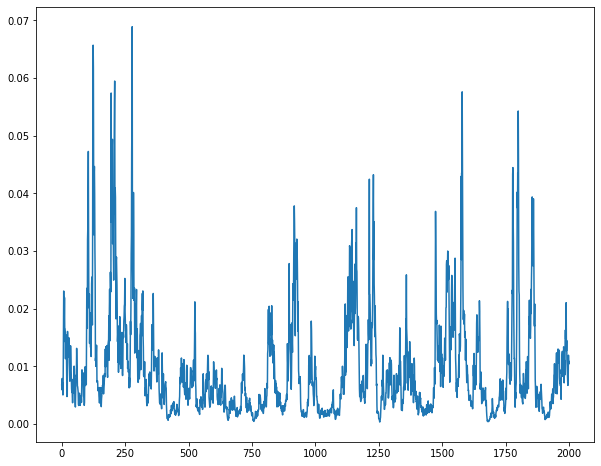

In [ ]:
def fOU_process_and_RFSV_20000pointday(H, nu, m, alpha) : 
    n = 2000
    X = np.zeros(n + 1)
    Y = np.zeros(n + 1)
    X[0] = X_0
    Y[0] = np.exp(X_0)
    for i in range(n):
        W = FBM(n = 20000, hurst = H, length = 1, method='daviesharte').fbm()
        tempX=np.zeros(20000 + 1)
        tempX[0]=X[i]
        for j in range(20000):
          tempX[(j+1)] = tempX[j] + nu*(W[(j+1)] - W[j]) + delta*alpha*(m - tempX[j])
        X[i+1]=tempX[-1]
        Y[i+1]=np.exp(tempX[-1])
    return Y

plt.figure(figsize = (10, 8))
X = fOU_process_and_RFSV_20000pointday(H, nu, m, alpha)
print(X)
plt.plot(X)

In [ ]:
%%time
plt.figure(figsize = (10, 8))
plt.plot(Y)
plt.show()

# Forecasting

### Log vol prediction

In [ ]:
Lags = [1, 5, 20]
def forecast_espe_logvol(SPx, H, n, Lag) : 
    res = 0.
    for s in range(n) : 
            res += SPx['log_rv'][s]/((n - s + Lag)*(n - s)**(Lag + 1./2.))
    log_vol = (np.cos(H*np.pi)/np.pi)*(Lag**(H+ 1. / 2.)) * res
    return log_vol

forecast_espe_logvol(SPx, H, Lag)
  

### Variance prediction

In [ ]:

H = 0.14
Lags = [1, 5, 20]
deltas = np.arange(1, 100)
def forecast_var(SPx, H, Lags, deltas) :
    zeta_SPx,reg = zeta(SPx, 2, deltas)
    nu2 = np.exp(reg[0])
    c = gamma(3./2 - H)/(gamma(H + 1./2.)*gamma(2 - 2*H))
    log_vol = forecast_espe_logvol(SPx, H, Lags)
    var_predict = np.zeros(len(Lags))
    for i in range(len(Lags)) : 
        var_predict[i] = np.exp(log_vol[i] + 2*c*nu2*(Lags[i]**(2*H)))
    return var_predict

Ratio P

In [ ]:
def ratio_P_AP(df, H, delta,p) : 
    model = AR(df['log_rv'])
    model_fit = model.fit(maxlag=p)
    pred = model_fit.predict(p)
    N = len(pred)
    num = np.zeros(N)
    deno = np.zeros(N)
    for k in range(500,N-delta) : 
        num[k] = (df['log_rv'][k+delta] -  pred[k+delta])**2
        deno[k] = (df['log_rv'][k+delta] - np.mean(df['log_rv']))**2
    return np.cumsum(num)[-1]/np.cumsum(deno)[-1]

In [ ]:
def ratio_P_RFSV(df, H, delta) : 
    N = len(df['log_rv'])
    num = np.zeros(N)
    deno = np.zeros(N)
    for k in range(500,N-delta) : 
        pred = forecast_espe_logvol(df, H, k, delta)
        num[k] = (df['log_rv'][k+delta] -  pred)**2
        deno[k] = (df['log_rv'][k+delta] - np.mean(df['log_rv']))**2
    return np.cumsum(num)[-1]/np.cumsum(deno)[-1]

In [ ]:
P = pd.DataFrame(columns = ['AR(5)','AR(10)','HAR(3)','RFSV'], index = ['SPX.rv $\Delta$ = 1', 'SPX.rv $\Delta$ = 5','SPX.rv $\Delta$ = 20'])
P['AR(5)'] = [ratio_P_AP(SPx,H,i,5) for i in [1,5,20]]
P['AR(10)'] = [ratio_P_AP(SPx,H,i,10) for i in [1,5,20]]
P 